# Crescent Visibility – Exploratory Data Analysis (EDA)

This notebook explores a large dataset related to lunar crescent visibility.
The goal is to understand the structure of the data, inspect feature distributions,
identify correlations, and motivate feature engineering choices before modeling.

This notebook is exploratory in nature.  
All final, reproducible data processing and modeling code is implemented in the `src/` directory.


In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 
from matplotlib.colors import ListedColormap 
%matplotlib inline
sns.set_style("whitegrid")


## Load raw data
We load the raw CSV file and inspect its structure 

In [228]:
df = pd.read_csv(r"C:\Users\miled\OneDrive\Documents\GitHub\crescent-visibility-analysis\data\raw\Final.csv")
df.head

<bound method NDFrame.head of          Ref No  Year  Month  Day    Lat    Long    TZ   M  V  O  ... Moonset  \
0     ICOP33JUT  2021      4   20  32.22 -110.97  -7.0  NE  I  M  ...   19:02   
1     ICOP41SAF  2019      9   30  35.78   -5.80   1.0  OA  V  M  ...    8:01   
2     ICOP41SAF  2019      9   30  -7.97  111.50   7.0  NE  V  M  ...   23:31   
3     ICOP41SAF  2019      9   30  -7.57  110.83   7.0  NE  V  M  ...   23:34   
4     ICOP34JUT  2013      7   10  -7.57  110.83   7.0  NE  I  M  ...    0:01   
...         ...   ...    ...  ...    ...     ...   ...  .. .. ..  ...     ...   
8023  Yallop139  1978      1    9  27.70  -82.70  -4.0  NE  V  E  ...     NaN   
8024  Yallop167  1985      1   21  19.00 -155.00 -10.0  NE  V  E  ...     NaN   
8025  Yallop205  1920      4   19  43.50    7.00   2.0  NE  V  E  ...     NaN   
8026   Yallop81  1901      4   19  50.70   -2.80   1.0  NE  V  E  ...     NaN   
8027   Yallop82  1908      2    3  56.00   -3.20   1.0  NE  V  E  ...     NaN  

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8028 entries, 0 to 8027
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ref No                 8028 non-null   object 
 1   Year                   8028 non-null   int64  
 2   Month                  8028 non-null   int64  
 3   Day                    8028 non-null   int64  
 4   Lat                    8028 non-null   float64
 5   Long                   8028 non-null   float64
 6   TZ                     8022 non-null   float64
 7   M                      8028 non-null   object 
 8   V                      8028 non-null   object 
 9   O                      8028 non-null   object 
 10  I                      7053 non-null   object 
 11  Ele                    8028 non-null   float64
 12  NE                     1493 non-null   object 
 13  B                      808 non-null    object 
 14  T                      418 non-null    object 
 15  CCD 

In [230]:
df.describe()

,Year,Month,Day,Lat,Long,TZ,Ele,LT,MA,JD,ArcV,ArcL,DAZ,W,MAlt
count,8028.000000,8028.000000,8028.000000,8028.000000,8028.000000,8022.000000,8028.000000,7878.000000,7313.000000,7.954000e+03,7954.000000,7954.000000,7954.000000,7954.000000,7954.000000
mean,1779.008097,6.464998,15.799078,24.800906,26.102677,2.255703,383.484865,35.937989,17.729978,2.370312e+06,10.274486,13.652416,7.518817,31.558230,8.880195
std,665.800717,3.346245,8.724490,18.712270,54.278058,3.385338,554.465758,49.768218,19.503727,2.441924e+05,5.123107,5.916892,6.494525,31.627449,5.184541
min,-567.000000,1.000000,1.000000,-44.000000,-155.500000,-10.000000,-5434.680000,-1403.330000,-42.070000,1.514073e+06,-30.560000,0.260000,0.000000,0.010000,-32.560000
25%,1999.000000,4.000000,9.000000,21.420000,5.930000,1.000000,26.450000,21.355000,13.350000,2.451403e+06,7.110000,9.482500,3.032500,13.000000,5.520000
50%,2011.000000,6.000000,16.000000,31.900000,35.600000,3.000000,119.520000,46.400000,22.030000,2.455951e+06,10.110000,13.040000,6.420000,24.280000,8.700000
75%,2016.000000,9.000000,24.000000,33.782500,50.000000,3.000000,617.590000,65.000000,30.210000,2.457604e+06,13.340000,17.440000,10.480000,43.295000,12.040000
max,2021.000000,12.000000,31.000000,60.880000,174.760000,13.000000,4145.000000,379.330000,45.980000,2.459408e+06,36.810000,113.080000,265.480000,1367.860000,35.740000


## Feature overview 
Key variables used in this project include:
- **Lat,Long** : Geographic location of observation
- **ArcV,ArcL** : Arc of Vision and Arc of Light
- **DAZ** : Diiference in azimuth(the horizontal angle or compass direction of an object, measured in degrees clockwise from a reference direction, usually true north)
- **JD** : Julian date (a continuous count of days and fractions of a day since noon on January 1, 4713 B.C)
- **Ele** : Elevation
- **Sunset,Moonset** : Astronomical event times
- **LT** : Local Time 
- **MA** : Magnetic Angle
- **Malt** : Magnetic Local Time 
- **V** : Visibility label(V = Visible, I = Invisible)


## Missing values analysis

In [231]:
df.isnull().sum()

Ref No                      0
Year                        0
Month                       0
Day                         0
Lat                         0
Long                        0
TZ                          6
M                           0
V                           0
O                           0
I                         975
Ele                         0
NE                       6535
B                        7220
T                        7610
CCD                      7452
witness                  3784
Cloud Condition          3784
Atmoshperic Condition    3784
Sunset                     74
Moonset                   150
LT                        150
MA                        715
JD                         74
ArcV                       74
ArcL                       74
DAZ                        74
W                          74
MAlt                       74
Ref No.1                    0
dtype: int64

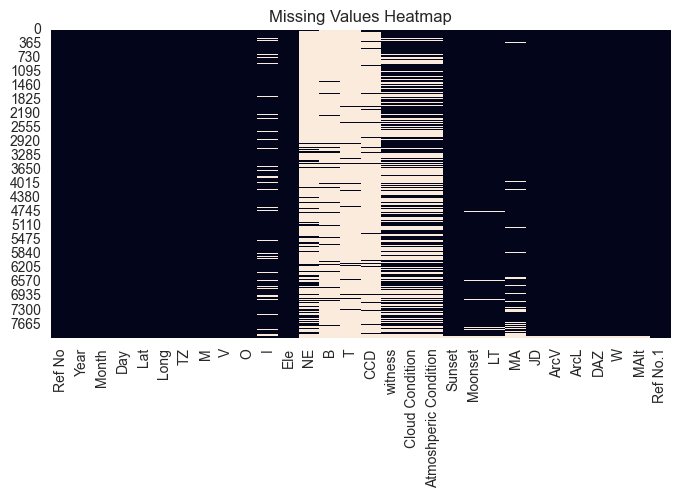

In [232]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


## Distribution of visibility classes

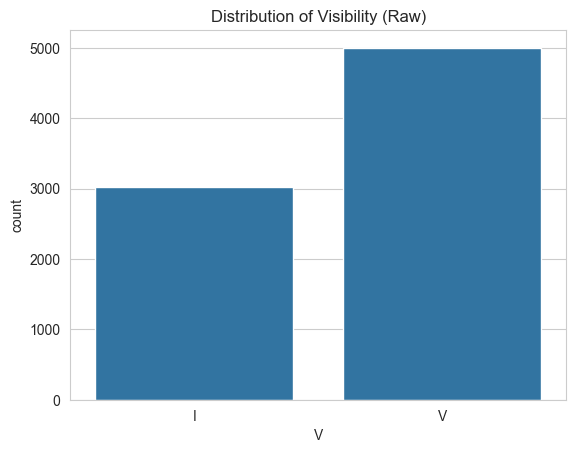

In [233]:
sns.countplot(x="V", data=df)
plt.title("Distribution of Visibility (Raw)")
plt.show()


## Feature engineering : Moonset-sunset Lag
We compute the time difference between moonset and sunset and analyse its ditribution


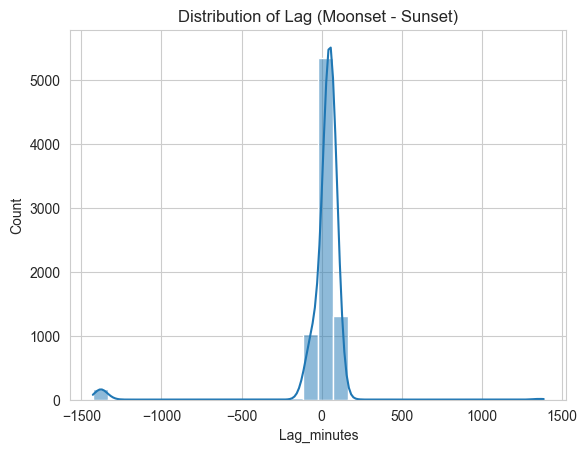

In [234]:
df["Sunset"] = pd.to_datetime(df["Sunset"], format="%H:%M", errors="coerce")
df["Moonset"] = pd.to_datetime(df["Moonset"], format="%H:%M", errors="coerce")

df["Lag_minutes"] = (df["Moonset"] - df["Sunset"]).dt.total_seconds() / 60

sns.histplot(df["Lag_minutes"], bins=30, kde=True)
plt.title("Distribution of Lag (Moonset - Sunset)")
plt.show()


## Encode visiblity label

We convert visibility labels into a binary variable for modeling

In [235]:
df["Visibility"] = df["V"].map({"V": 1, "I": 0})



## Feature distributions 

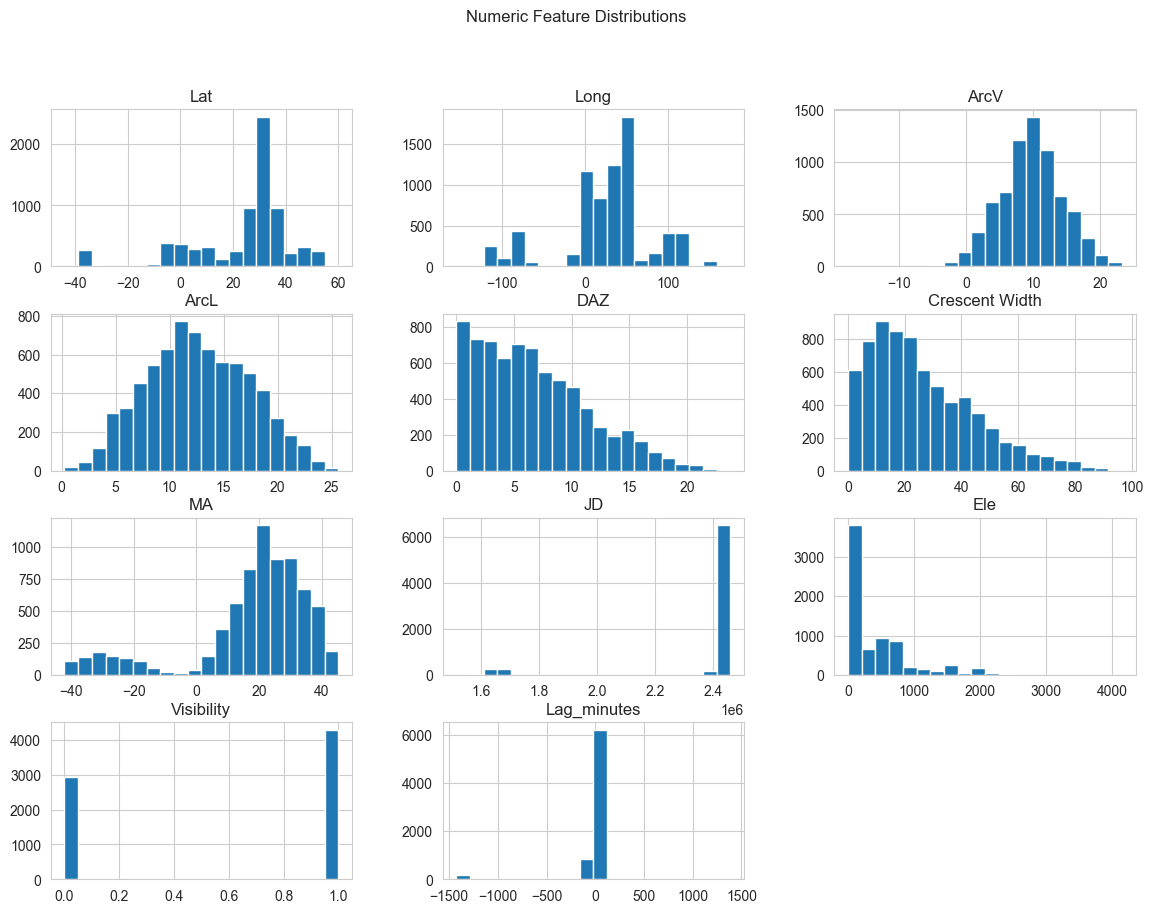

In [236]:
df = pd.read_csv(r"C:\Users\miled\OneDrive\Documents\GitHub\crescent-visibility-analysis\data\processed\cleaned_data.csv")
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(bins=20, figsize=(14,10))
plt.suptitle("Numeric Feature Distributions")
plt.show()


## Geographic Distribution of Visibility Observations

We project observations on a world map to examine geographic patterns.


In [237]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Long"], df["Lat"]),
    crs="EPSG:4326"
)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

gdf["Visibility_label"] = gdf["Visibility"].map({0: "Invisible", 1: "Visible"})


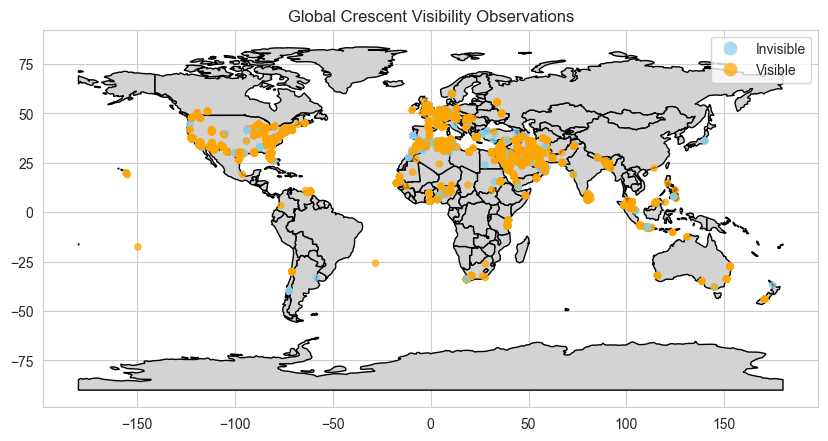

In [238]:
fig, ax = plt.subplots(figsize=(10,6))
world.plot(ax=ax, color="lightgray", edgecolor="black")
gdf.plot(
    ax=ax,
    column="Visibility_label",
    categorical=True,
    cmap=ListedColormap(["skyblue", "orange"]),
    legend=True,
    markersize=20,
    alpha=0.7
)
plt.title("Global Crescent Visibility Observations")
plt.show()


## Visibility-Specific Geographic Patterns

We separate visible and invisible observations to better compare spatial behavior.


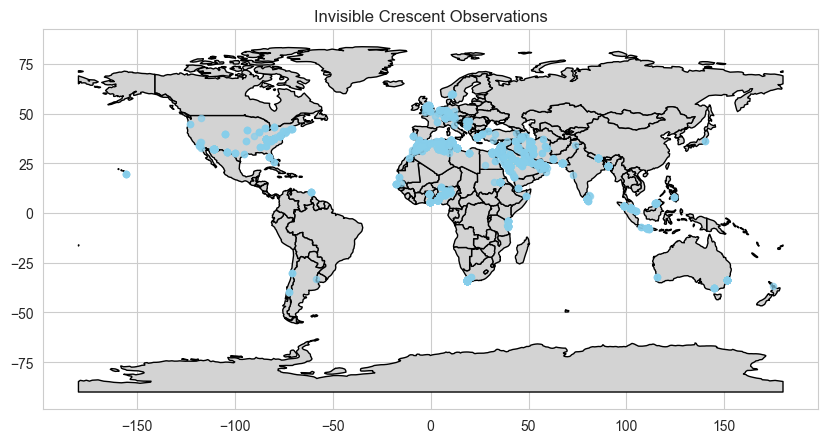

In [239]:
fig, ax = plt.subplots(figsize=(10,6))
world.plot(ax=ax, color="lightgray", edgecolor="black")
gdf[gdf["Visibility"]==0].plot(
    ax=ax, color="skyblue", markersize=20, alpha=0.7
)
plt.title("Invisible Crescent Observations")
plt.show()


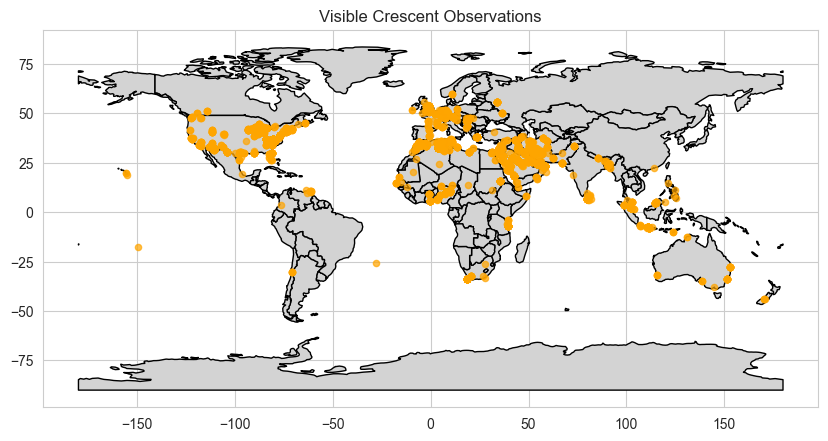

In [240]:
fig, ax = plt.subplots(figsize=(10,6))
world.plot(ax=ax, color="lightgray", edgecolor="black")
gdf[gdf["Visibility"]==1].plot(
    ax=ax, color="orange", markersize=20, alpha=0.7
)
plt.title("Visible Crescent Observations")
plt.show()


## Correlation analysis

We examine linear correlations between numeric features to identify redundancy and potential predictors .

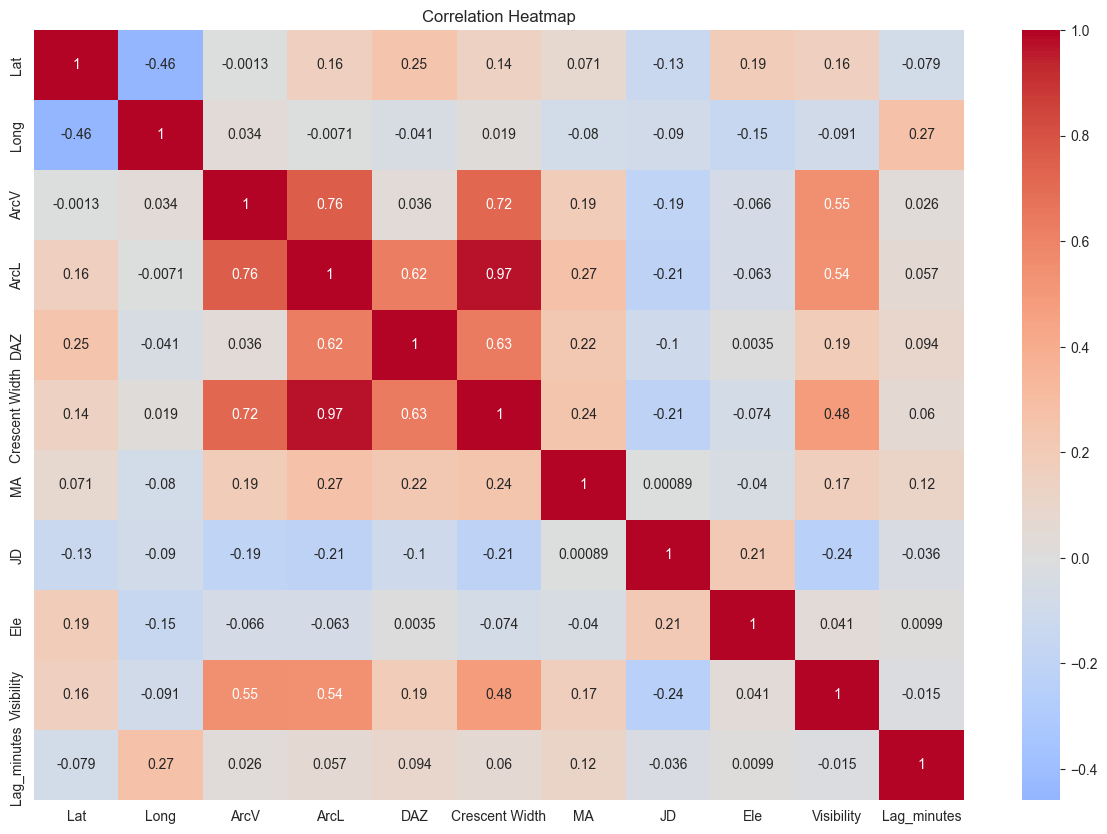

In [242]:
plt.figure(figsize=(15,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


## Interpetaions : 
- **Longitude and TZ** are basically the same and they relay the same information ( considering Time zones are dependant on the longitude ) so we are going to drop TZ.
- **JD and Year** : they relay the same information by knowing we can deduce the other , no need to have them both.
- **ArcV and MAlt** :they are correlated one is enough.
- Some features show moderate correlation with each other, like ArcV DAZ W MAlt 
